# Soma + dendrite compartmental linear: pipeline theory vs simulation

$$\lambda^S_i=\Big[E^S_i+\textstyle\sum_j w^{SS}_{ij}\,(g^S_i*n^S_j)+\sum_j w^{SD}_{ij}\,(g^S_i*n^D_j)\Big]_+,\qquad p^D_i=\mathrm{clip}\Big(E^D_i+\textstyle\sum_j w^{DS}_{ij}\,(g^D_i*n^S_j)+\sum_j w^{DD}_{ij}\,(g^D_i*n^D_j),\,0,1\Big).$$


Comparison notebook for `theories/single_pop_dendritic_linear.theory.py`.

**Dynamics:**
- Soma fires Poisson with rate `λ_S_i = max(0, ES_i + Σ_j wSS[i,j](gS_i ⊛ nS_j) + Σ_j wSD[i,j](gS_i ⊛ nD_j))`
- Dendrite fires per somatic spike with probability `p_D_i = clip(ED_i + Σ_j wDS[i,j](gD_i ⊛ nS_j) + Σ_j wDD[i,j](gD_i ⊛ nD_j), 0, 1)`
- Exponential post-synaptic filters: `gS_i(t) = (1/tauS_i) e^{-t/tauS_i}`, `gD_i(t) = (1/tauD_i) e^{-t/tauD_i}`

The framework's existing multivariate Taylor handles the Bernoulli CGF `log(1 + (e^nDt - 1)·p_D)` from the action.  The simulator caps `p_D` at 1 (paper convention) — this is a known finite source of theory/sim mismatch in regions of high somatic drive.

## 1. Setup

In [1]:
%display latex
%matplotlib inline

import os, sys, time, importlib, importlib.util
import numpy as np
import matplotlib.pyplot as plt

import os, sys
# --- depth-robust repo root: walk up until we find the 'pipeline' package ---
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ so relative data paths resolve as before

# shared demo engine (load -> run -> plot); notebooks/ on path for the import
if os.path.join(_root, 'notebooks') not in sys.path:
    sys.path.insert(0, os.path.join(_root, 'notebooks'))
import nb_support as nb

from models.dendritic_linear_sim_numba import (
    sim_dendritic_linear_numba,
    build_sim_arrays,
    flat_index_of,
    stack_binned_counts,
)
from models.cumulant_estimator import compute_kpoint_slice

## 2. Configuration

`fundamental` provides numerical values for every parameter declared in `theories/single_pop_dendritic_linear.theory.py`.  All four weight matrices and both time-constant vectors are sized to the declared population `E` (size 2).

In [2]:
fundamental = {
    'wSS':  [[0.0, 0.0], [0.0, 0.0]],
    'wSD':  [[0.1, 0.0], [0.0, 0.1]],
    'wDS':  [[0.1, 0.1], [0.1, 0.1]],
    'wDD':  [[0.0, 0.0], [0.0, 0.0]],
    'tauS': [1.0, 1.0],
    'tauD': [1.0, 1.0],
    'ES':   [0.5, 0.5],
    'ED':   [0.5, 0.5],
}

# Theory side
k        = 2
max_ell  = 0
# Choose which two legs to compare — somatic OR dendritic spikes (or mix).
external_fields = [('nS', 1), ('nS', 2)]

# τ grid (theory + sim share this)
tau_max  = 20.0
tau_step = 0.25

# Pipeline parallelism
PARALLEL  = True
N_WORKERS = None

# Simulation knobs
N_RUNS   = 4
T_sim    = float(2_000_000)
dt_sim   = 0.01
dt_bin   = 0.25

# Cap p_D at 1 in the simulator (paper convention).  Set False for a
# diagnostic run where the Binomial would raise on prob > 1 — useful
# only when sweeping parameters into the linear-regime border.
CAP_PD_AT_ONE = True

print(f'k={k}, max_ell={max_ell}, external_fields={external_fields}')
print(f'tau_max={tau_max}, tau_step={tau_step}')
print(f'PARALLEL={PARALLEL}, N_WORKERS={N_WORKERS}')
print(f'N_RUNS={N_RUNS}, T_sim={T_sim:.0g}, dt_sim={dt_sim}, dt_bin={dt_bin}')
print(f'CAP_PD_AT_ONE={CAP_PD_AT_ONE}')

k=2, max_ell=0, external_fields=[('nS', 1), ('nS', 2)]
tau_max=20.0000000000000, tau_step=0.250000000000000
PARALLEL=True, N_WORKERS=None
N_RUNS=4, T_sim=2e+06, dt_sim=0.0100000000000000, dt_bin=0.250000000000000
CAP_PD_AT_ONE=True


## 3. Load the theory file

In [3]:
THEORY_NAME = 'single_pop_dendritic_linear'

# Load via the shared engine (theories/<name>.theory.py -> (model dict, module)).
model, theory_mod = nb.load_theory(THEORY_NAME)
print(f'Loaded theory: {model["name"]!r}')
print(f'Populations: {[(p["name"], p["size"]) for p in model["populations"]]}')
print(f'Fields (physical): {[f["name"] for f in model["physical_fields"]]}')
print(f'Kernels: {[k["name"] for k in model["kernels"]]}')
print(f'stability_analysis: {model.get("stability_analysis", False)}')
print(f'Equations:')
for eq in model['equations']:
    print(f'  [{eq["kind"]}]  {eq["lhs_text"]}  =  {eq["rhs_text"]}')

Loaded theory: 'Single pop Dendritic Linear'
Populations: [('E', 2)]
Fields (physical): ['dnS', 'dnD']
Kernels: ['gS', 'gD']
stability_analysis: False
Equations:
  [algebraic]  nS[i]  =  ES[i] + sum(wSS[i,j]*nS[j] + wSD[i,j]*nD[j] for j in E)
  [algebraic]  nD[i]  =  nS[i]*(ED[i] + sum(wDS[i,j]*nS[j] + wDD[i,j]*nD[j] for j in E))


## 4. Theory side — one pipeline call

Full MSR-JD chain: `FieldTheory.expand` → symbolic propagator `K` → `solve_mean_field_dae` → numerical poles + residues → Phase-J τ-grid evaluation.

Because both equations are algebraic (no `Dt`), the DAE solver runs with `stability_analysis=False` (the theory's declared default).  The multi-start Newton finds the unique low-rate physical saddle; the high-rate runaway root that would require `p_D > 1` is outside the seed box.

In [4]:
# Run the full MSR-JD chain through the shared engine.  Config carries the
# SAME k / max_ell / external_fields / fundamental / tau-grid as before, so
# the numerics are identical to a direct compute_cumulants(...) call.
cfg = nb.Config(
    k               = k,
    max_ell         = max_ell,
    external_fields = external_fields,   # ('nS', i) -> normalized to fluctuation 'dnS'
    fundamental     = fundamental,
    tau_max         = tau_max,
    tau_step        = tau_step,
    parallel        = PARALLEL,
    verbose         = True,
)

t0 = time.perf_counter()
th = nb.run(model, cfg, theory_mod)       # returns exactly what compute_cumulants returns (+ _cfg/_model/_resolved)
print(f'\nTheory side took {time.perf_counter() - t0:.1f}s')

# --- shim: legacy variable names the sim / diagnostic / plot cells reference ---
tau_grid_th    = th['tau_grid']
C_theory_total = th['C_tau'].real
C_by_ell       = th['C_tau_by_ell']
C_theory_tree  = (C_by_ell[0].real if 0 in C_by_ell
                  else np.zeros_like(C_theory_total))
C_theory_loop  = C_theory_total - C_theory_tree

mf_values = th['mf_values']
print('\nMean-field saddles:')
for name, vals in mf_values.items():
    print(f'  {name!r:8} = {vals}')

print(f'\nTotal diagrams: {len(th["diagrams"])}')
n_per_ell = {ell: sum(1 for r in th['diagrams'] if r['ell'] == ell)
             for ell in sorted({r['ell'] for r in th['diagrams']})}
for ell, n_d in n_per_ell.items():
    print(f'    ell={ell}: {n_d} diagrams')

[1/7] FieldTheory.expand (taylor_order=2)...


[expand-cache] hit at order=2 (exact, no filter)
=== Sanity checks ===
  [PASS]  (n_tilde=0, n_phys=0)  constant term
  [PASS]  (n_tilde=1, n_phys=0)  tadpole — must vanish at MF saddle
  [PASS]  (n_tilde=0, n_phys=1)  linear physical-only — must vanish at EOM
      vtypes: 0, sources: 4 (NoiseSourceType: 0)

      ── MF action (bigrade ≤1 in each index; vanishes at saddle) ──
      bigrade (1, 0):
        nDt1  *  (-nDstar1*nSstar1*wDD11 - nDstar2*nSstar1*wDD12 - nSstar1^2*wDS11 - nSstar1*nSstar2*wDS12 - ED1*nSstar1 + nDstar1)
        nDt2  *  (-nDstar1*nSstar2*wDD21 - nDstar2*nSstar2*wDD22 - nSstar1*nSstar2*wDS21 - nSstar2^2*wDS22 - ED2*nSstar2 + nDstar2)
        nSt1  *  (-nDstar1*wSD11 - nDstar2*wSD12 - nSstar1*wSS11 - nSstar2*wSS12 - ES1 + nSstar1)
        nSt2  *  (-nDstar1*wSD21 - nDstar2*wSD22 - nSstar1*wSS21 - nSstar2*wSS22 - ES2 + nSstar2)

      ── Free action (1,1) bilinear sector ──


        nDt1·dnD1  *  (-nSstar1*wDD11*z_gD_1 + 1)
        nDt1·dnD2  *  (-nSstar1*wDD12*z_gD_1)
        nDt1·dnS1  *  (-nSstar1*wDS11*z_gD_1 - nDstar1*wDD11 - nDstar2*wDD12 - nSstar1*wDS11 - nSstar2*wDS12 - ED1)
        nDt1·dnS2  *  (-nSstar1*wDS12*z_gD_1)
        nDt2·dnD1  *  (-nSstar2*wDD21*z_gD_2)
        nDt2·dnD2  *  (-nSstar2*wDD22*z_gD_2 + 1)
        nDt2·dnS1  *  (-nSstar2*wDS21*z_gD_2)
        nDt2·dnS2  *  (-nSstar2*wDS22*z_gD_2 - nDstar1*wDD21 - nDstar2*wDD22 - nSstar1*wDS21 - nSstar2*wDS22 - ED2)
        nSt1·dnD1  *  (-wSD11*z_gS_1)
        nSt1·dnD2  *  (-wSD12*z_gS_1)
        nSt1·dnS1  *  (-wSS11*z_gS_1 + 1)
        nSt1·dnS2  *  (-wSS12*z_gS_1)
        nSt2·dnD1  *  (-wSD21*z_gS_2)
        nSt2·dnD2  *  (-wSD22*z_gS_2)
        nSt2·dnS1  *  (-wSS21*z_gS_2)
        nSt2·dnS2  *  (-wSS22*z_gS_2 + 1)

      ── Interaction action (total degree ≥ 2, excluding (1,1)) ──


      bigrade (2,0):
        nDt1^2  *  (1/2*nDstar1^2*nSstar1*wDD11^2 + nDstar1*nDstar2*nSstar1*wDD11*wDD12 + 1/2*nDstar2^2*nSstar1*wDD12^2 + nDstar1*nSstar1^2*wDD11*wDS11 + nDstar2*nSstar1^2*wDD12*wDS11 + 1/2*nSstar1^3*wDS11^2 + nDstar1*nSstar1*nSstar2*wDD...)
        nDt2^2  *  (1/2*nDstar1^2*nSstar2*wDD21^2 + nDstar1*nDstar2*nSstar2*wDD21*wDD22 + 1/2*nDstar2^2*nSstar2*wDD22^2 + nDstar1*nSstar1*nSstar2*wDD21*wDS21 + nDstar2*nSstar1*nSstar2*wDD22*wDS21 + 1/2*nSstar1^2*nSstar2*wDS21^2 + nDstar1...)
        nSt1^2  *  (-1/2*nDstar1*wSD11 - 1/2*nDstar2*wSD12 - 1/2*nSstar1*wSS11 - 1/2*nSstar2*wSS12 - 1/2*ES1)
        nSt2^2  *  (-1/2*nDstar1*wSD21 - 1/2*nDstar2*wSD22 - 1/2*nSstar1*wSS21 - 1/2*nSstar2*wSS22 - 1/2*ES2)

      [expand] done in 2.44s
[2/7] Build propagator (K_ker → K_ft → G_ft → D_delta)...
[propagator] Loaded from cache: saved_theories/single_pop_dendritic_linear/propagator.sobj

      ── K_ker (shape 4 × 4) ──
        rows (response): ['nSt1', 'nSt2', 'nDt1', 'nDt2']
     

[propagator] polynomial-fracfield: Q(ω) degree 4, 4 retarded pole(s) found.
[propagator] 4 retarded poles (Im(ω) > 0) — exact polynomial path:
  ω_1 = +0.000000 + (+0.862136) i
  ω_2 = -0.000000 + (+0.939354) i
  ω_3 = +0.000000 + (+1.000000) i
  ω_4 = -0.000000 + (+1.077218) i

      ── C_mats (residue matrix at each pole) ──
        rows (response): ['nSt1', 'nSt2', 'nDt1', 'nDt2']
        cols (physical): ['dnS1', 'dnS2', 'dnD1', 'dnD2']
      C_mats[0]  (residue at ω_1 = +0.0000+0.8621i):
        [0,0] = +4.418416e-02+2.356624e-13j
        [0,1] = +4.418416e-02-4.304271e-13j
        [0,2] = +3.204912e-02+9.403413e-17j
        [0,3] = +3.204912e-02-3.789190e-13j
        [1,0] = +4.418416e-02-4.304271e-13j
        [1,1] = +4.418416e-02+2.356624e-13j
        [1,2] = +3.204912e-02-3.789190e-13j
        [1,3] = +3.204912e-02+9.403413e-17j
        [2,0] = +6.091400e-02-5.872219e-14j
        [2,1] = +6.091400e-02-4.626763e-13j
        [2,2] = +4.418416e-02+2.356624e-13j
        [2,3] = +4

      [phase_j] done in 0.28s

Done.  k=2, max_ell=0, 4 unique diagrams, 161 τ points.

  Phase wall summary (Σ = 3.3s):
    expand          2.44s  (74.7%)
    propagator      0.04s  ( 1.2%)
    mean_field      0.13s  ( 3.9%)
    poles           0.36s  (11.0%)
    diagrams        0.01s  ( 0.4%)
    classify        0.01s  ( 0.4%)
    phase_j         0.28s  ( 8.5%)

Theory side took 3.3s

Mean-field saddles:
  'nSstar' = [0.5322804737416126, 0.5322804737416125]
  'nDstar' = [0.32280473741612536, 0.3228047374161253]

Total diagrams: 4
    ell=0: 4 diagrams


## 5. Simulation side

Translate the model + numerical parameters + MF saddle into the per-array sim inputs, JIT-warmup, then run `N_RUNS` independent runs with different seeds.  Stack somatic + dendritic spike counts so the same cumulant estimator handles either leg.

In [5]:
import secrets as _secrets

arr = build_sim_arrays(model, fundamental, mf_values)
N             = arr['N']
wSS, wSD      = arr['wSS'], arr['wSD']
wDS, wDD      = arr['wDS'], arr['wDD']
tauS, tauD    = arr['tauS'], arr['tauD']
ES, ED        = arr['ES'], arr['ED']
stack_offsets = arr['stack_offsets']

print(f'Neuron count: N = {N}')
print(f'tauS  = {tauS}')
print(f'tauD  = {tauD}')
print(f'ES    = {ES}')
print(f'ED    = {ED}')
print('wSS =\n', wSS)
print('wSD =\n', wSD)
print('wDS =\n', wDS)
print('wDD =\n', wDD)
print(f'\nMF predictions:  nS* = {arr["nS_mf"]},  nD* = {arr["nD_mf"]}')

Neuron count: N = 2
tauS  = [1. 1.]
tauD  = [1. 1.]
ES    = [0.5 0.5]
ED    = [0.5 0.5]
wSS =
 [[0. 0.]
 [0. 0.]]
wSD =
 [[0.1 0. ]
 [0.  0.1]]
wDS =
 [[0.1 0.1]
 [0.1 0.1]]
wDD =
 [[0. 0.]
 [0. 0.]]

MF predictions:  nS* = [0.53228047 0.53228047],  nD* = [0.32280474 0.32280474]


In [6]:
# Discretization
n_steps        = int(T_sim / dt_sim)
bin_size_steps = max(int(round(dt_bin / dt_sim)), 1)
dt_bin_eff     = bin_size_steps * dt_sim
n_bins         = n_steps // bin_size_steps
max_lag_bins   = int(tau_max / dt_bin_eff)
tau_sim_grid   = np.arange(-max_lag_bins, max_lag_bins + 1) * dt_bin_eff

# Map external_fields to flat sim rows.
pop_indices = [flat_index_of(stack_offsets, ef[0], ef[1])
               for ef in external_fields]
field_types = [ef[0] for ef in external_fields]
print(f'External fields {external_fields} → stacked rows {pop_indices}')

# JIT warmup — first numba call compiles the function.
_ = sim_dendritic_linear_numba(
    int(1000), float(dt_sim),
    wSS, wSD, wDS, wDD,
    tauS, tauD,
    ES, ED,
    int(bin_size_steps), int(100), int(0),
    CAP_PD_AT_ONE,
)
print('JIT warmup done.')

External fields [('nS', 1), ('nS', 2)] → stacked rows [0, 1]


JIT warmup done.


In [7]:
# Run the full simulation N_RUNS times with independent seeds.
BASE_SEED   = _secrets.randbits(31)
C_sim_runs  = []
rate_S_runs = []
rate_D_runs = []
prob_D_runs = []

t0 = time.perf_counter()
for run in range(N_RUNS):
    seed = int(BASE_SEED + run)
    nS_b, nD_b, lamS_b, pD_b, totS, totD = sim_dendritic_linear_numba(
        int(n_steps), float(dt_sim),
        wSS, wSD, wDS, wDD,
        tauS, tauD,
        ES, ED,
        int(bin_size_steps), int(n_bins), seed,
        CAP_PD_AT_ONE,
    )
    rate_S_runs.append([float(totS[i]) / T_sim for i in range(N)])
    rate_D_runs.append([float(totD[i]) / T_sim for i in range(N)])
    prob_D_runs.append(pD_b.mean(axis=1))

    binned_stacked = stack_binned_counts(nS_b, nD_b)
    # Theory leg sweep: one None, others 0.
    lag_bins = [None] + [0] * (k - 1)
    _tau_sim, C_slice = compute_kpoint_slice(
        binned_stacked, dt_bin_eff,
        pop_indices, lag_bins, max_lag_bins,
        field_types=field_types,
    )
    C_sim_runs.append(C_slice)
    print(f'  run {run + 1}/{N_RUNS} seed={seed}  '
          f'nS_rate={rate_S_runs[-1]}  nD_rate={rate_D_runs[-1]}')

rate_S_arr = np.asarray(rate_S_runs)
rate_D_arr = np.asarray(rate_D_runs)
prob_D_arr = np.asarray(prob_D_runs)
C_sim_arr  = np.asarray(C_sim_runs)
C_sim_mean = C_sim_arr.mean(axis=0).real
C_sim_se   = (C_sim_arr.real.std(axis=0, ddof=1)
              / np.sqrt(N_RUNS) if N_RUNS > 1
              else np.zeros_like(C_sim_mean))
print(f'\nSimulation took {time.perf_counter() - t0:.1f}s for {N_RUNS} runs')

  run 1/4 seed=197294415  nS_rate=[0.531983, 0.531977]  nD_rate=[0.324266, 0.3239515]


  run 2/4 seed=197294416  nS_rate=[0.5320255, 0.5337485]  nD_rate=[0.324829, 0.326031]


  run 3/4 seed=197294417  nS_rate=[0.5333865, 0.5324105]  nD_rate=[0.3257135, 0.324636]


  run 4/4 seed=197294418  nS_rate=[0.532349, 0.532153]  nD_rate=[0.3249715, 0.3247175]

Simulation took 44.3s for 4 runs


## 6. Theory vs simulation

Top: per-neuron empirical rates (somatic / dendritic / Bernoulli probability) vs MF predictions.  Bottom: `C^{(2)}(τ)` two-point cumulant slice between the chosen external legs.

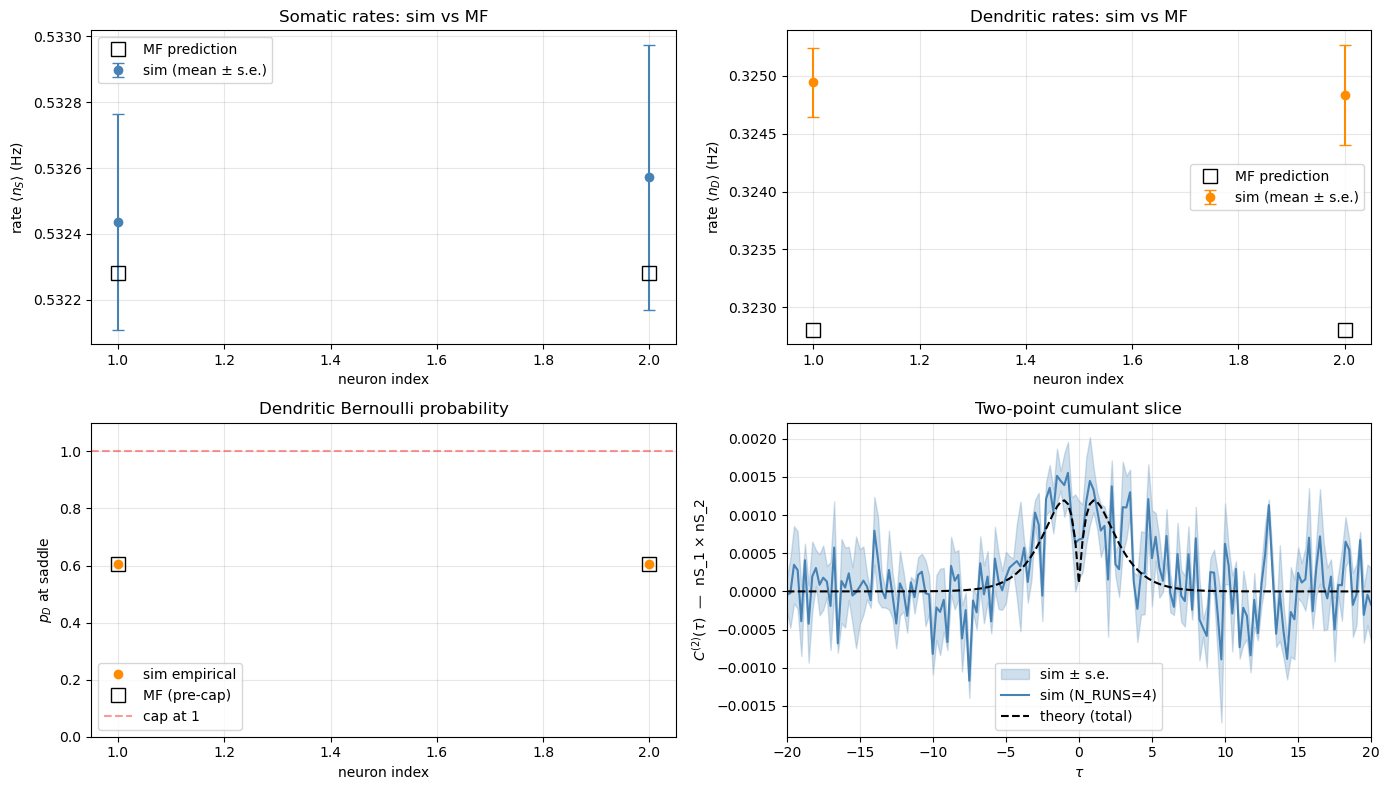

In [8]:
rate_S_mean = rate_S_arr.mean(axis=0)
rate_S_se   = (rate_S_arr.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
               if N_RUNS > 1 else np.zeros(N))
rate_D_mean = rate_D_arr.mean(axis=0)
rate_D_se   = (rate_D_arr.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
               if N_RUNS > 1 else np.zeros(N))
prob_D_mean = prob_D_arr.mean(axis=0)

# Saddle predictions
nS_pred = arr['nS_mf']
nD_pred = arr['nD_mf']
# Dendritic Bernoulli prob at saddle (linear pre-cap)
pD_pred = np.array([ED[i] + sum(wDS[i, j] * nS_pred[j] + wDD[i, j] * nD_pred[j]
                                for j in range(N))
                    for i in range(N)])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# (top-left) somatic rates
ax = axes[0, 0]
neuron_idx = np.arange(1, N + 1)
ax.errorbar(neuron_idx, rate_S_mean, yerr=rate_S_se,
            fmt='o', color='steelblue', label='sim (mean ± s.e.)', capsize=4)
ax.plot(neuron_idx, nS_pred, 's', color='black', label='MF prediction', markersize=10, mfc='none')
ax.set_xlabel('neuron index')
ax.set_ylabel('rate $\\langle n_S \\rangle$ (Hz)')
ax.set_title('Somatic rates: sim vs MF')
ax.legend()
ax.grid(True, alpha=0.3)

# (top-right) dendritic rates
ax = axes[0, 1]
ax.errorbar(neuron_idx, rate_D_mean, yerr=rate_D_se,
            fmt='o', color='darkorange', label='sim (mean ± s.e.)', capsize=4)
ax.plot(neuron_idx, nD_pred, 's', color='black', label='MF prediction', markersize=10, mfc='none')
ax.set_xlabel('neuron index')
ax.set_ylabel('rate $\\langle n_D \\rangle$ (Hz)')
ax.set_title('Dendritic rates: sim vs MF')
ax.legend()
ax.grid(True, alpha=0.3)

# (bottom-left) Bernoulli probability
ax = axes[1, 0]
ax.plot(neuron_idx, prob_D_mean, 'o', color='darkorange', label='sim empirical')
ax.plot(neuron_idx, pD_pred, 's', color='black', label='MF (pre-cap)', markersize=10, mfc='none')
ax.axhline(1.0, color='red', linestyle='--', alpha=0.4, label='cap at 1')
ax.set_xlabel('neuron index')
ax.set_ylabel('$p_D$ at saddle')
ax.set_title('Dendritic Bernoulli probability')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, max(1.1, pD_pred.max() * 1.1))

# (bottom-right) C^{(2)}(τ)
ax = axes[1, 1]
label_legs = ' × '.join(f'{ef[0]}_{ef[1]}' for ef in external_fields)
if N_RUNS > 1:
    ax.fill_between(tau_sim_grid,
                    C_sim_mean - C_sim_se,
                    C_sim_mean + C_sim_se,
                    color='steelblue', alpha=0.25, label='sim ± s.e.')
ax.plot(tau_sim_grid, C_sim_mean,
        color='steelblue', label=f'sim (N_RUNS={N_RUNS})')
ax.plot(tau_grid_th, C_theory_total,
        color='black', linestyle='--', label='theory (total)')
if max_ell >= 1:
    ax.plot(tau_grid_th, C_theory_tree,
            color='gray', linestyle=':', label='theory tree (ell=0)')
ax.set_xlabel(r'$\tau$')
ax.set_ylabel(rf'$C^{{({k})}}(\tau)$  —  {label_legs}')
ax.set_title('Two-point cumulant slice')
ax.set_xlim(-tau_max, tau_max)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

Two-compartment (soma + dendrite) linear compartmental model, 2 populations: the soma fires
Poisson with a rectified linear rate and each dendrite fires per somatic spike with a
clipped-linear Bernoulli probability, both driven through exponential post-synaptic filters.
The notebook compares the pipeline's $C^{(2)}(\tau)$ against a numba simulation; the known
mismatch source is the simulator's $p_D$ cap at 1 (the MSR-JD Bernoulli action does not cap).

**Knobs:**
* **`fundamental`** — the weight matrices `wSS, wSD, wDS, wDD`, the filter time constants
  `tauS, tauD`, and the resting drives `ES, ED`.
* **`k`, `max_ell`** — correlator order and loop order (`max_ell=1` for the 1-loop correction).
* **`external_fields`** — somatic / dendritic / mixed legs (e.g. `[('nS',1),('nD',1)]`).
* **`CAP_PD_AT_ONE`** — whether the simulator caps the dendritic probability at 1 (paper convention).
* **`tau_max`, `tau_step`** — the $\tau$ grid; **`N_RUNS`, `T_sim`, `dt_sim`, `dt_bin`** — simulation knobs.

**Probing the cap mismatch:** sweep `ED` (or external drive) toward the boundary and re-compare —
expect theory > sim in $|C^{(2)}|$ as the capped-bin fraction climbs.